In [1]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


from sklearn.ensemble import StackingClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
# Cargar el dataset
df = pd.read_csv(r'C:\Users\User\Documents\DAVID2\proyecto_credit_card_fraud\data\credit_card_frauds.csv')
# Visualizar las primeras filas
print("--- Primeras 5 filas del dataset ---")
display(df.head())

# Información general de las columnas y tipos de datos
print("\n--- Información general del DataFrame ---")
df.info()

# Resumen estadístico de las variables numéricas
print("\n--- Resumen estadístico ---")
display(df.describe())

# Comprobar si hay valores nulos
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())

--- Primeras 5 filas del dataset ---


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0



--- Información general del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float6

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000



--- Valores nulos por columna ---
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [8]:
# Conteo de la variable objetivo
print(df['is_fraud'].value_counts())

# Conteo en porcentaje para ver el desbalanceo
print(df['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    337825
1      1782
Name: count, dtype: int64
is_fraud
0    99.475276
1     0.524724
Name: proportion, dtype: float64


In [9]:
# ==============================================================================
# 5. ANÁLISIS DE CARDINALIDAD (Funcionalidad adicional)
# ==============================================================================

# Seleccionamos las columnas de tipo 'object' (categóricas)
columnas_categoricas = df.select_dtypes(include=['object']).columns

# Creamos un resumen de valores únicos
analisis_cardinalidad = pd.DataFrame({
    'Variable': columnas_categoricas,
    'Valores Únicos': [df[col].nunique() for col in columnas_categoricas]
}).sort_values(by='Valores Únicos', ascending=False)

print("--- Resumen de Cardinalidad ---")
print(analisis_cardinalidad)

--- Resumen de Cardinalidad ---
                Variable  Valores Únicos
7              trans_num          339607
0  trans_date_trans_time          338504
1               merchant             693
6                    dob             187
3                   city             176
5                    job             163
2               category              14
4                  state              13


--- Resumen de Outliers ---
amt: 18043 registros (5.31%)
city_pop: 65168 registros (19.19%)
age: 0 registros (0.00%)
lat: 6612 registros (1.95%)
long: 6598 registros (1.94%)


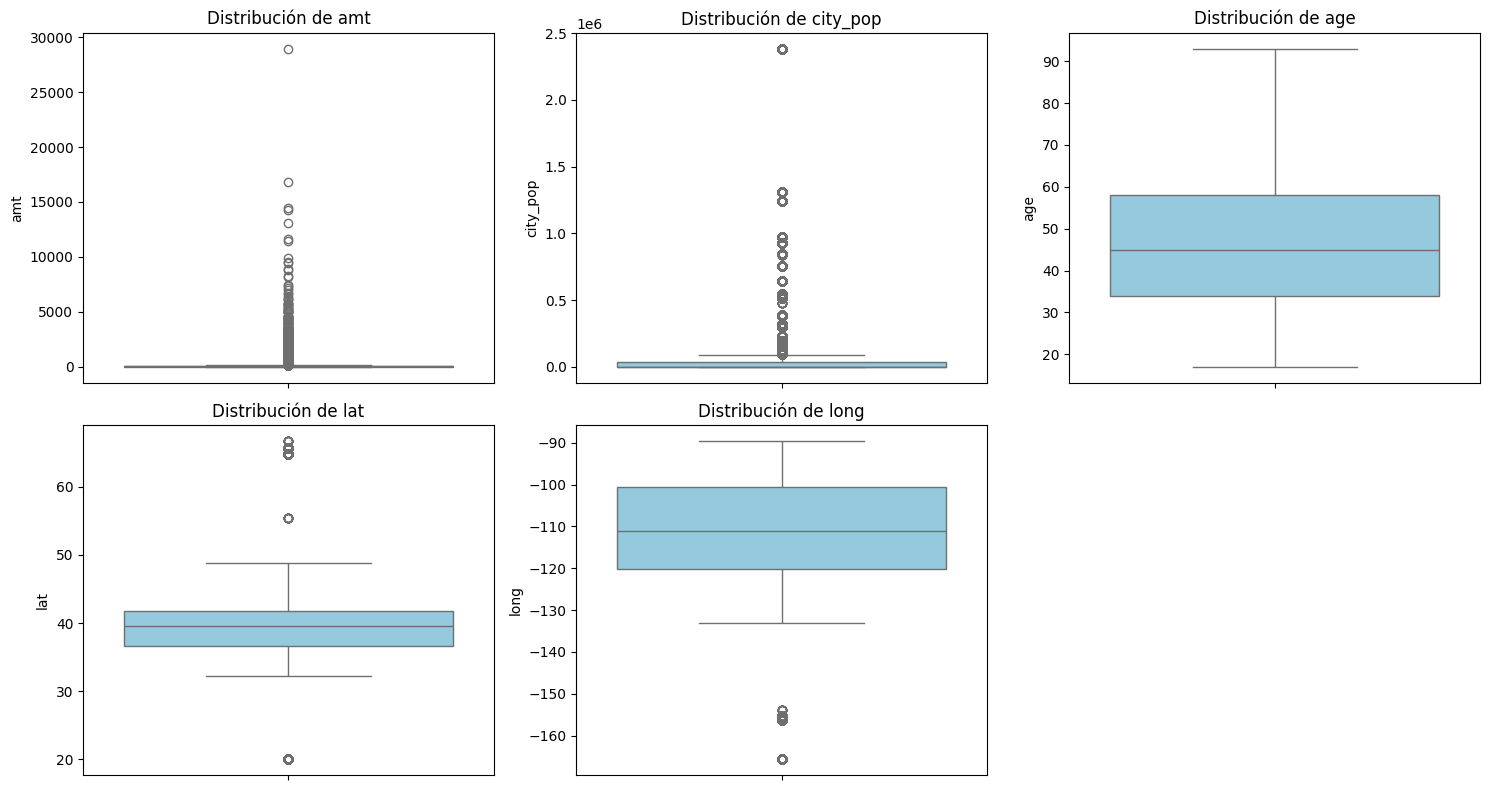

In [ ]:
# ==============================================================================
# 6. ANÁLISIS DE OUTLIERS 
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas numéricas a analizar
num_cols = ['amt', 'city_pop', 'age', 'lat', 'long']

# 1. Cálculo cuantitativo (Método IQR)
print("--- Resumen de Outliers ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

# 2. Visualización mediante Boxplots
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 7. LIMPIEZA Y PREPARACIÓN FINAL
# ==============================================================================

# Convertir fechas para extraer variables numéricas útiles
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Creamos variables numéricas (Ingeniería de variables)
df['hour'] = df['trans_date_trans_time'].dt.hour
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Seleccionamos las columnas que usaremos (cumpliendo >11 características)
# Incluimos 'category' y 'state' para tratarlas después del split
features_to_keep = [
    'amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 
    'hour', 'age', 'category', 'state'
]

X = df[features_to_keep]
y = df['is_fraud']

In [11]:
# 1. División en entrenamiento y prueba (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Codificación de las 2 variables categóricas (Requisito mínimo)
from sklearn.preprocessing import LabelEncoder
le_cat = LabelEncoder()
le_state = LabelEncoder()

X_train['category'] = le_cat.fit_transform(X_train['category'])
X_test['category'] = le_cat.transform(X_test['category'])

X_train['state'] = le_state.fit_transform(X_train['state'])
X_test['state'] = le_state.transform(X_test['state'])

In [31]:
X_train.shape()

TypeError: 'tuple' object is not callable

In [13]:
# 7.1. Definición de los modelos base (Algoritmos de clase)
# Usamos parámetros que aseguren que el modelo no sea "una caja negra"
modelos_base = [
    ('logit', LogisticRegression(max_iter=500, solver='lbfgs')),
    ('arbol', DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

# 7.2. Definición del Meta-Modelo (El "juez" final)
meta_modelo = LogisticRegression()

# 7.3. Configuración del Stacking
stacking_model = StackingClassifier(
    estimators=modelos_base,
    final_estimator=meta_modelo,
    cv=5,      # Validación cruzada interna
    n_jobs=-1  # Usa todos los núcleos del procesador para ir más rápido
)

In [14]:
# 8.1. Ejecución del entrenamiento
print("Iniciando el entrenamiento del modelo ensamble (Stacking)...")

# Entrenamos con los datos que preparamos antes
stacking_model.fit(X_train, y_train)

print("---")
print("✅ Entrenamiento finalizado.")
print(f"Modelos base entrenados: {[name for name, _ in modelos_base]}")

Iniciando el entrenamiento del modelo ensamble (Stacking)...
---
✅ Entrenamiento finalizado.
Modelos base entrenados: ['logit', 'arbol', 'knn']


In [15]:
# 9.1. Generación de predicciones sobre el conjunto de test
y_pred = stacking_model.predict(X_test)

# 9.2. Obtención de probabilidades (necesario para la curva ROC)
y_probs = stacking_model.predict_proba(X_test)[:, 1]

print("✅ Predicciones generadas correctamente sobre los datos de prueba.")

✅ Predicciones generadas correctamente sobre los datos de prueba.


In [16]:
# 10.1. Informe detallado por clase
print("--- INFORME DE CLASIFICACIÓN DETALLADO ---")
print(classification_report(y_test, y_pred, target_names=['Legítima (0)', 'Fraude (1)']))

# 10.2. Cálculo del AUC-ROC
auc = roc_auc_score(y_test, y_probs)
print(f"Área bajo la curva ROC (AUC): {auc:.4f}")

--- INFORME DE CLASIFICACIÓN DETALLADO ---
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     67566
  Fraude (1)       0.87      0.57      0.69       356

    accuracy                           1.00     67922
   macro avg       0.93      0.79      0.85     67922
weighted avg       1.00      1.00      1.00     67922

Área bajo la curva ROC (AUC): 0.9732


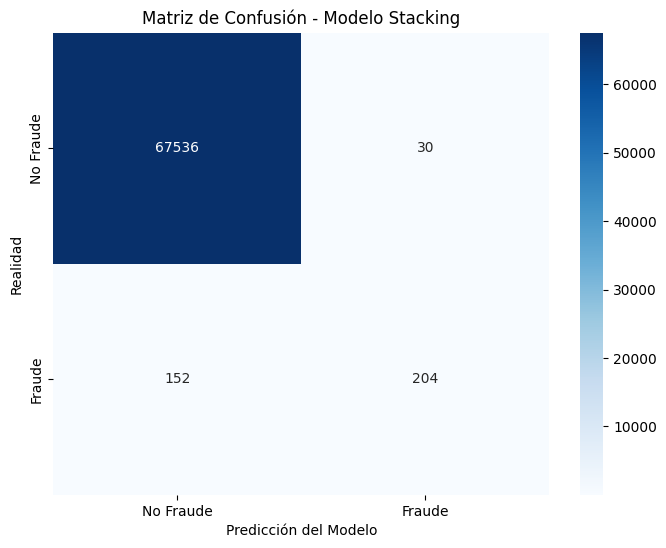

In [17]:
# 11.1. Creación de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# 11.2. Visualización con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])

plt.title('Matriz de Confusión - Modelo Stacking')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

In [24]:
from sklearn.metrics import f1_score, accuracy_score

# 16.1. Creamos un diccionario para comparar los modelos base
comparativa = {}

# 16.2. Evaluamos cada modelo que vive dentro del Stacking
# (Usamos los nombres que pusimos: 'logit', 'arbol', 'knn')
for nombre, modelo in stacking_model.named_estimators_.items():
    # Predecimos con cada uno
    y_pred_individual = modelo.predict(X_test)
    
    # Guardamos métricas
    comparativa[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred_individual),
        'F1-Score': f1_score(y_test, y_pred_individual)
    }

# 16.3. Añadimos el resultado del Stacking Final
y_pred_final = stacking_model.predict(X_test)
comparativa['STACKING'] = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'F1-Score': f1_score(y_test, y_pred_final)
}

# 16.4. Mostramos la tabla
df_comparativa = pd.DataFrame(comparativa).T
print("--- COMPARATIVA DE MODELOS (SIN ESCALADO) ---")
print(df_comparativa)

--- COMPARATIVA DE MODELOS (SIN ESCALADO) ---
          Accuracy  F1-Score
logit     0.005241  0.010428
arbol     0.866464  0.003516
knn       0.307721  0.008393
STACKING  0.857969  0.004540


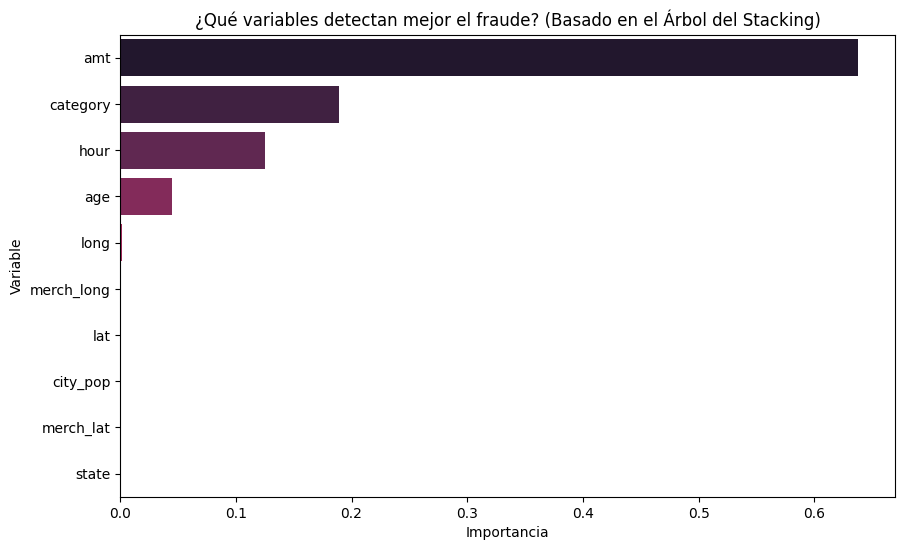

In [26]:
# 19.1. Extraemos la importancia de las variables del modelo de Árbol (el que mejor funciona)
modelo_arbol = stacking_model.named_estimators_['arbol']
importancias = modelo_arbol.feature_importances_

# 19.2. Creamos un DataFrame para visualizarlo
feature_importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 19.3. Gráfico de importancia
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='rocket')
plt.title('¿Qué variables detectan mejor el fraude? (Basado en el Árbol del Stacking)')
plt.show()

VAMOS A VER QUE CAMBIA SI ESCALAMOS LOS DATOS


In [27]:
# 20.1. Aplicamos el escalado (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 20.2. Re-entrenamos el mismo Stacking de antes pero con datos escalados
print("Entrenando el Stacking con datos ESCALADOS...")
stacking_model.fit(X_train_scaled, y_train)

# 20.3. Generamos las nuevas predicciones
y_pred_scaled = stacking_model.predict(X_test_scaled)

Entrenando el Stacking con datos ESCALADOS...


In [28]:
   # 21.1. Calculamos métricas del nuevo modelo
comparativa_scaled = {}

for nombre, modelo in stacking_model.named_estimators_.items():
    pred_ind = modelo.predict(X_test_scaled)
    comparativa_scaled[nombre] = f1_score(y_test, pred_ind)

comparativa_scaled['STACKING'] = f1_score(y_test, y_pred_scaled)

# 21.2. Lo comparamos con vuestros datos anteriores
df_impacto = pd.DataFrame({
    'F1 Sin Escalar': [0.0104, 0.0035, 0.0083, 0.0045], # Datos que me pasaste
    'F1 Con Escalado': [comparativa_scaled['logit'], comparativa_scaled['arbol'], 
                        comparativa_scaled['knn'], comparativa_scaled['STACKING']]
}, index=['logit', 'arbol', 'knn', 'STACKING'])

print("--- IMPACTO DEL ESCALADO EN EL F1-SCORE ---")
print(df_impacto)

--- IMPACTO DEL ESCALADO EN EL F1-SCORE ---
          F1 Sin Escalar  F1 Con Escalado
logit             0.0104         0.000000
arbol             0.0035         0.664348
knn               0.0083         0.686308
STACKING          0.0045         0.724541


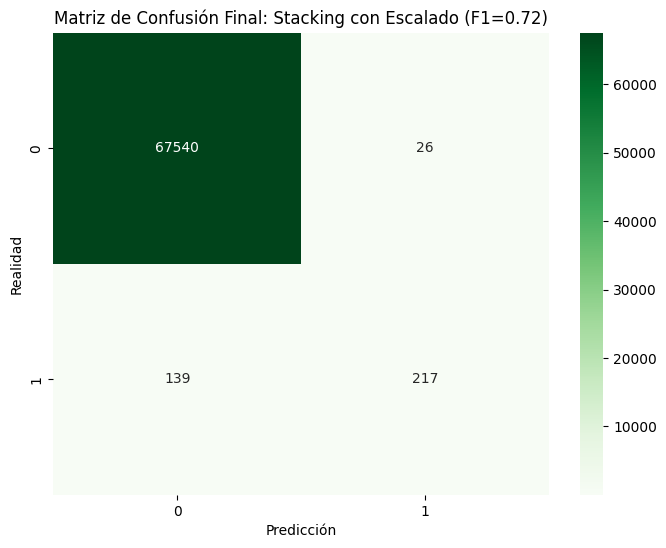

In [29]:
# 23. Matriz de Confusión Final (La buena)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_final = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión Final: Stacking con Escalado (F1=0.72)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()